In [1]:
import numpy as np
import matplotlib.pyplot as plt

from thinkdsp import decorate

## Задание 8.2

Начнем с гауссова окна, как в примере главы.

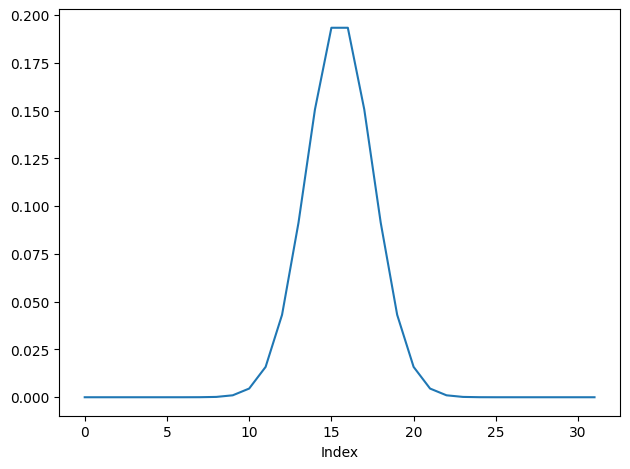

In [3]:
import scipy.signal
from scipy.signal.windows import gaussian as gaussian_

gaussian = gaussian_(M=32, std=2)
gaussian /= sum(gaussian)
plt.plot(gaussian)
decorate(xlabel='Index')

FFT гауссова окна:

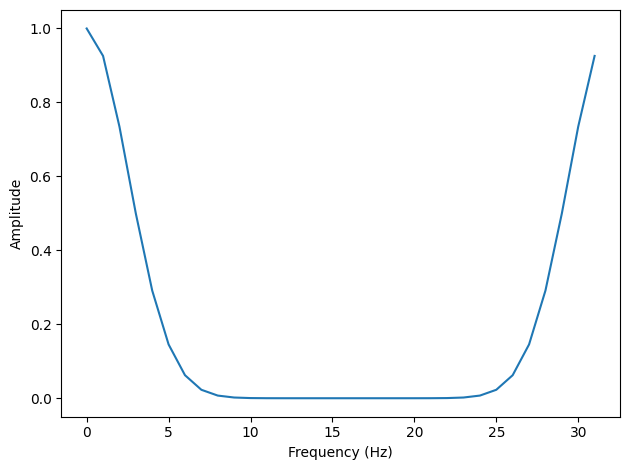

In [4]:
fft_gaussian = np.fft.fft(gaussian)
plt.plot(abs(fft_gaussian))
decorate(xlabel='Frequency (Hz)', ylabel='Amplitude')

После сдвига частот видно, что спектр тоже похож на гауссиану.

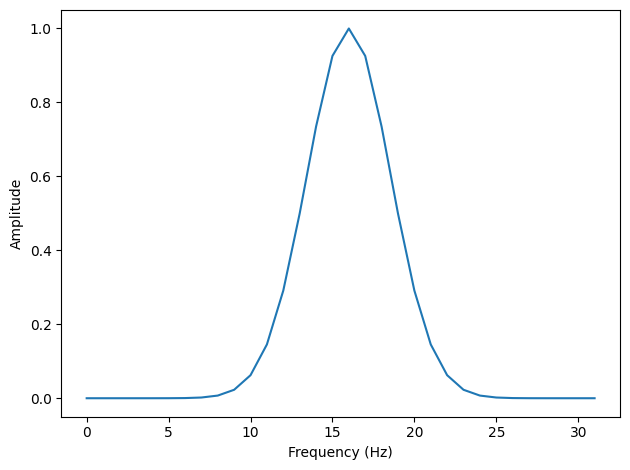

In [5]:
N = len(gaussian)
fft_rolled = np.roll(fft_gaussian, N//2)
plt.plot(abs(fft_rolled))
decorate(xlabel='Frequency (Hz)', ylabel='Amplitude')

Функция сравнивает окно и его FFT рядом.

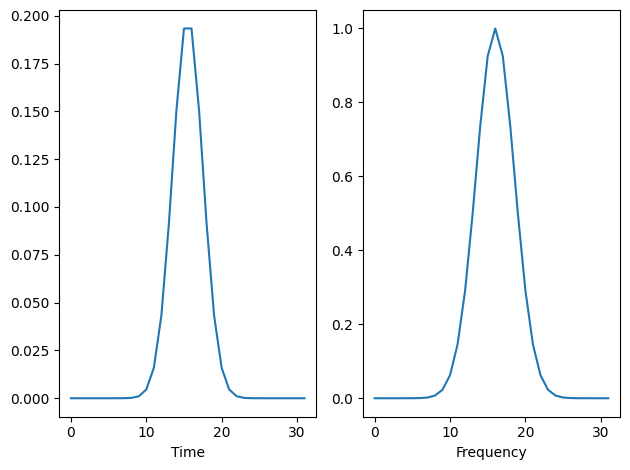

In [7]:
def plot_gaussian_(std):
    M = 32
    gaussian = gaussian_(M=M, std=std)
    gaussian /= sum(gaussian)
    
    plt.subplot(1, 2, 1)
    plt.plot(gaussian)
    decorate(xlabel='Time')

    fft_gaussian = np.fft.fft(gaussian)
    fft_rolled = np.roll(fft_gaussian, M//2)
    
    plt.subplot(1, 2, 2)
    plt.plot(np.abs(fft_rolled))
    decorate(xlabel='Frequency')
    plt.show()

plot_gaussian_(2)

Интерактивно посмотрим влияние `std`.

In [ ]:
from ipywidgets import interact, interactive, fixed
import ipywidgets as widgets

slider = widgets.FloatSlider(min=0.1, max=10, value=2)
interact(plot_gaussian_, std=slider);

interactive(children=(FloatSlider(value=2.0, description='std', max=10.0, min=0.1), Output()), _dom_classes=('…

При увеличении `std` окно расширяется, а его FFT сужается.

Вывод: преобразование Фурье гауссианы снова похоже на гауссиану, а ширины во времени и частоте связаны обратно.

## Задание 8.3

Создадим тестовый сигнал с частотой дискретизации 44.1 кГц.

In [10]:
from thinkdsp import SquareSignal

signal = SquareSignal(freq=440)
wave = signal.make_wave(duration=1.0, framerate=44100)

Сравним несколько окон одинаковой длины.

In [12]:
M = 15
std = 2.5

gaussian = gaussian_(M=M, std=std)   
bartlett = np.bartlett(M)
blackman = np.blackman(M)
hamming = np.hamming(M)
hanning = np.hanning(M)

windows = [blackman, gaussian, hanning, hamming]
names = ['blackman', 'gaussian', 'hanning', 'hamming']

for window in windows:
    window /= sum(window)

Формы окон:

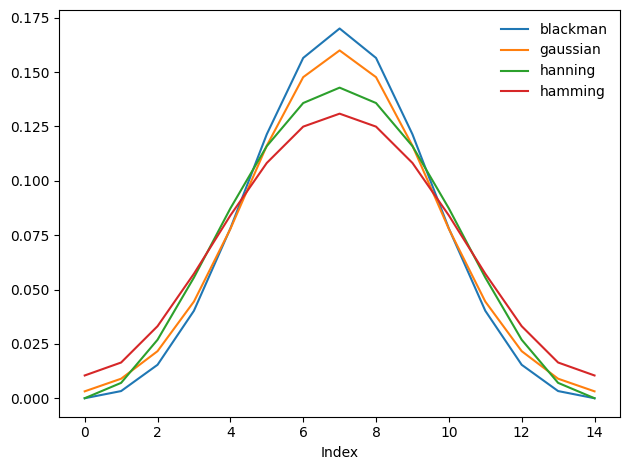

In [13]:
for window, name in zip(windows, names):
    plt.plot(window, label=name)

decorate(xlabel='Index')

Теперь сравним их DFT.

In [14]:
def zero_pad(array, n):
    """Extends an array with zeros.

    array: NumPy array
    n: length of result

    returns: new NumPy array
    """
    res = np.zeros(n)
    res[:len(array)] = array
    return res

In [15]:
def plot_window_dfts(windows, names):
    """
    """
    for window, name in zip(windows, names):
        padded =  zero_pad(window, len(wave))
        dft_window = np.fft.rfft(padded)
        plt.plot(abs(dft_window), label=name)

Hamming спадает быстрее, Blackman медленнее, у Hanning заметны боковые лепестки.

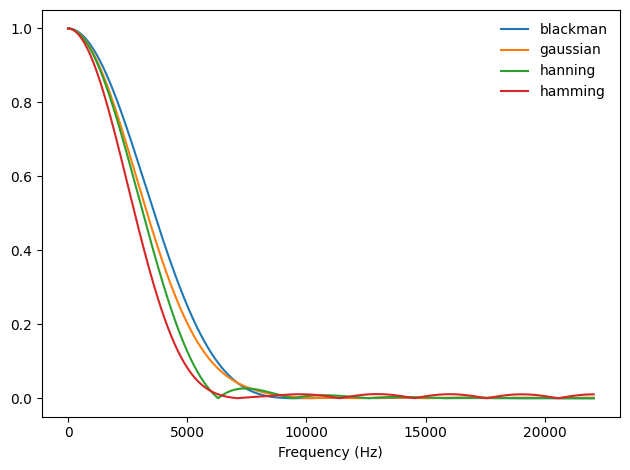

In [16]:
plot_window_dfts(windows, names)
decorate(xlabel='Frequency (Hz)')

То же сравнение в логарифмическом масштабе.

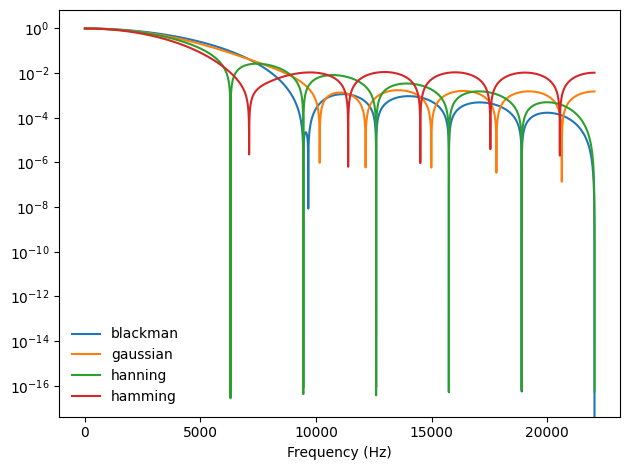

In [17]:
plot_window_dfts(windows, names)
decorate(xlabel='Frequency (Hz)', yscale='log')

На log-шкале Hamming и Hanning быстрее падают в начале, но боковые лепестки различаются.

Вывод: выбор окна меняет утечку спектра, а Hanning дает хороший компромисс между спадом и боковыми лепестками.